# Safe Infrastructure or Risk Signal? Predicting Serious Collision Severity around Pedestrian Crossing Facilities in London

## Preparation

- [Github link](google.com) *[Optional]*

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

传统道路安全研究关注宏观环境变量（天气、路面、速度限制）。建成环境研究用5D框架理解路口风险（Chen et al., 2026）。但5D框架忽略了路口设施层面的细节，比如行人过街设施的角色。这些设施通常被理解为protective infrastructure，但它们同时也标记了高冲突、高行人流的路口环境。本研究用可解释机器学习检验：crossing facilities在预测严重事故时，是保护性因素还是高风险路口语境的信号？

## Research questions

[[ go back to the top ]](#Table-of-contents)

Are pedestrian crossing facilities associated with lower serious-collision severity in London, or do they act as signals of high-risk junction contexts in machine learning predictions?

RQ1: How do severe collision rates vary across pedestrian crossing facility types and junction contexts in London in 2024?

RQ2: Can machine learning models identify serious or fatal collisions in London, and which road-context variables contribute most to severity prediction?

## Data

[[ go back to the top ]](#Table-of-contents)

In [152]:
# 3.1 Install and import

%pip install shap statsmodels --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import requests
import shap
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score,
    recall_score, f1_score, accuracy_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve
)

warnings.filterwarnings('ignore')
print("All packages imported successfully")

Note: you may need to restart the kernel to use updated packages.
All packages imported successfully


In [153]:
# 3.2 Load collision and casualty datasets from GitHub

COLLISION_URL = (
    'https://raw.githubusercontent.com/Alexia418/'
    'DSSS_Assessment/main/'
    'dft-road-casualty-statistics-collision-2024.csv'
)
CASUALTY_URL = (
    'https://raw.githubusercontent.com/Alexia418/'
    'DSSS_Assessment/main/'
    'dft-road-casualty-statistics-casualty-2024.csv'
)

collision = pd.read_csv(COLLISION_URL, low_memory=False)
casualty  = pd.read_csv(CASUALTY_URL,  low_memory=False)

print(f"Collision records (GB): {len(collision):,}")
print(f"Casualty records  (GB): {len(casualty):,}")

Collision records (GB): 100,927
Casualty records  (GB): 128,272


In [154]:
# 3.3 Filter to London using ONS district codes (E09 = London boroughs)

london_col = collision[
    collision['local_authority_ons_district']
    .astype(str).str.startswith('E09')
].copy()

london_cas = casualty[
    casualty['collision_index'].isin(london_col['collision_index'])
].copy()

print(f"London collisions: {len(london_col):,}")
print(f"London casualties: {len(london_cas):,}")
print(f"Unique boroughs:   {london_col['local_authority_ons_district'].nunique()}")

London collisions: 20,967
London casualties: 23,997
Unique boroughs:   33


In [155]:
# 3.4 Aggregate pedestrian casualties to collision level and join
# casualty_class = 3: Pedestrian; cross-validated against casualty_type = 0

ped = london_cas[london_cas['casualty_class'] == 3].copy()

ped_agg = ped.groupby('collision_index').agg(
    ped_casualty_count=('casualty_severity', 'count'),
    ped_severe_count=('casualty_severity', lambda x: (x.isin([1,2])).sum()),
    has_ped_casualty=('casualty_severity', lambda x: 1)
).reset_index()

london = london_col.merge(ped_agg, on='collision_index', how='left')
london['has_ped_casualty'] = london['has_ped_casualty'].fillna(0).astype(int)

print(f"Pedestrian casualties: {len(ped):,}")
print(f"Merged dataset rows:   {len(london):,}")

Pedestrian casualties: 4,445
Merged dataset rows:   20,967


In [156]:
# 3.5 Create binary target variable
# collision_severity: 1=Fatal, 2=Serious, 3=Slight (STATS19)

london['severe'] = london['collision_severity'].apply(
    lambda x: 1 if x in [1, 2] else 0
)

print(f"Severe cases: {london['severe'].sum():,} ({london['severe'].mean():.1%})")
print(f"Slight cases: {(london['severe']==0).sum():,}")

Severe cases: 3,601 (17.2%)
Slight cases: 17,366


In [157]:
# 3.6 Engineer temporal and spatial features

london['hour']        = london['time'].str[:2].astype(float)
london['peak_hour']   = london['hour'].apply(lambda x: 1 if (7<=x<=9) or (16<=x<=19) else 0)
london['weekend']     = london['day_of_week'].apply(lambda x: 1 if x in [1,7] else 0)
london['has_crossing'] = london['pedestrian_crossing_physical_facilities_historic'].apply(
    lambda x: 0 if x in [0, 9] else 1
)

print("Features created: hour, peak_hour, weekend, has_crossing")

Features created: hour, peak_hour, weekend, has_crossing


In [158]:
# 3.7 Compute borough-level severe collision rate as spatial context variable

borough_rate = (
    london.groupby('local_authority_ons_district')['severe']
    .mean()
    .rename('borough_severe_rate')
)
london = london.drop(columns=['borough_severe_rate'], errors='ignore').join(
    borough_rate, on='local_authority_ons_district'
)

print(f"Boroughs: {borough_rate.shape[0]}")
print(borough_rate.sort_values(ascending=False).head())

Boroughs: 33
local_authority_ons_district
E09000001    0.325301
E09000027    0.268437
E09000028    0.245714
E09000020    0.221631
E09000021    0.214533
Name: borough_severe_rate, dtype: float64


In [159]:
# 3.8 Inspect ambiguous and missing codes before exclusion

pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 120)

AMBIGUOUS_CODES = {
    'pedestrian_crossing_physical_facilities_historic': [-1, 99],
    'junction_detail':         [-1, 99],
    'junction_control':        [-1, 9],
    'road_type':               [-1, 9],
    'speed_limit':             [-1, 99],
    'light_conditions':        [-1],
    'weather_conditions':      [-1, 9],
    'road_surface_conditions': [-1, 9],
    'urban_or_rural_area':     [-1],
    'day_of_week':             [-1],
}

rows = []
for col, codes in AMBIGUOUS_CODES.items():
    if col not in london.columns:
        continue
    total      = len(london)
    ambig      = london[col].isin(codes).sum()
    nan        = london[col].isnull().sum()
    total_miss = ambig + nan
    rows.append({'variable': col, 'ambiguous': ambig,
                 'NaN': nan, 'total_missing': total_miss,
                 'pct': round(total_miss/total*100, 1)})

print(pd.DataFrame(rows).sort_values('pct', ascending=False).to_string(index=False))

                                        variable  ambiguous  NaN  total_missing  pct
                                junction_control       5880    0           5880 28.0
                                 junction_detail       2256    0           2256 10.8
                                       road_type       2216    0           2216 10.6
                              weather_conditions       1905    0           1905  9.1
                         road_surface_conditions       1625    0           1625  7.8
pedestrian_crossing_physical_facilities_historic        181    0            181  0.9
                                     speed_limit          0    0              0  0.0
                                light_conditions          0    0              0  0.0
                             urban_or_rural_area          0    0              0  0.0
                                     day_of_week          0    0              0  0.0


In [160]:
# 3.9 Define model features and target

FEATURES = [
    'pedestrian_crossing_physical_facilities_historic',
    'junction_detail', 'junction_control',
    'road_type', 'speed_limit', 'urban_or_rural_area',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'day_of_week', 'hour', 'peak_hour', 'weekend',
    'has_ped_casualty', 'borough_severe_rate', 'has_crossing',
]
TARGET = 'severe'

In [161]:
# 3.10 Remove rows with invalid codes and verify data quality

CODED_COLS = [
    'pedestrian_crossing_physical_facilities_historic',
    'junction_detail', 'junction_control', 'road_type', 'speed_limit',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'urban_or_rural_area', 'day_of_week',
]
INVALID = [-1, 99]

df_model = london[FEATURES + [TARGET]].copy()
for col in CODED_COLS:
    before = len(df_model)
    df_model = df_model[~df_model[col].isin(INVALID)]
    removed = before - len(df_model)
    if removed > 0:
        print(f"Removed {removed:>5} rows — {col}")

df_model = df_model.dropna()
print(f"\nFinal: {len(df_model):,} rows | Severe: {df_model[TARGET].sum():,} ({df_model[TARGET].mean():.1%})")

Removed   181 rows — pedestrian_crossing_physical_facilities_historic
Removed  2245 rows — junction_detail
Removed  4005 rows — junction_control

Final: 14,536 rows | Severe: 2,516 (17.3%)


In [162]:
# 3.11 Verify no remaining missing values

missing = df_model[FEATURES].isnull().sum()
print("Missing values:", "None" if missing.sum()==0 else missing[missing>0])
print(f"Shape: {df_model.shape}")

Missing values: None
Shape: (14536, 17)




| Variable | Source | Type | Description | Notes |
|---|---|---|---|---|
| severe | Collision | Binary | Target: 1 = Fatal/Serious, 0 = Slight | Derived from collision_severity |
| pedestrian_crossing_physical_facilities_historic | Collision | Categorical | Crossing facility type within 50m | Core variable of interest |
| junction_detail | Collision | Categorical | Junction type at collision location | |
| junction_control | Collision | Categorical | Traffic control type at junction | |
| road_type | Collision | Categorical | Road classification | |
| speed_limit | Collision | Numeric | Speed limit in mph | |
| urban_or_rural_area | Collision | Categorical | Urban or rural classification | |
| light_conditions | Collision | Categorical | Lighting at time of collision | |
| weather_conditions | Collision | Categorical | Weather at time of collision | |
| road_surface_conditions | Collision | Categorical | Road surface condition | |
| day_of_week | Collision | Categorical | Day of week | 1=Sunday, 7=Saturday |
| hour | Collision | Numeric | Hour of day | Derived from time field |
| peak_hour | Collision | Binary | Peak hour indicator | 1 = 07-09 or 16-19 |
| weekend | Collision | Binary | Weekend indicator | Derived from day_of_week |
| has_ped_casualty | Casualty | Binary | Pedestrian casualty involved | Derived from casualty join |
| borough_severe_rate | Collision | Numeric | Borough-level severe collision rate | Spatial context proxy |
| has_crossing | Collision | Binary | Crossing facility present within 50m | Derived from crossing variable |

In [163]:
# 3.12 Define categorical and numeric feature groups

CAT_FEATURES = [
    'pedestrian_crossing_physical_facilities_historic',
    'junction_detail', 'junction_control', 'road_type', 'urban_or_rural_area',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'day_of_week', 'peak_hour', 'weekend', 'has_ped_casualty', 'has_crossing',
]
NUM_FEATURES = ['speed_limit', 'hour', 'borough_severe_rate']

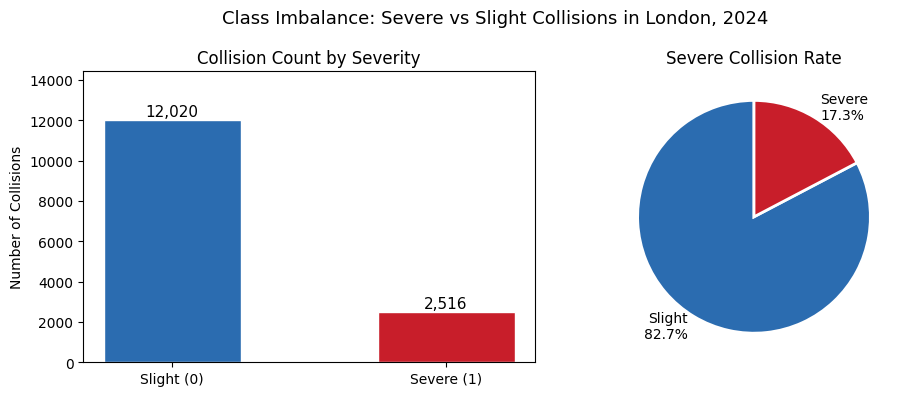

Severe rate: 0.173
Imbalance ratio: 4.8:1


In [ ]:
# 3.13 EDA 1: Severity class distribution

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

severity_counts = df_model['severe'].value_counts().sort_index()
severity_labels = ['Slight (0)', 'Severe (1)']
colors = ['#2B6CB0', '#C81E2A']

axes[0].bar(severity_labels, severity_counts.values,
            color=colors, edgecolor='white', width=0.5)
for bar, count in zip(axes[0].patches, severity_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{count:,}', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Collision Count by Severity')
axes[0].set_ylabel('Number of Collisions')
axes[0].set_ylim(0, severity_counts.max() * 1.2)

rates = [1 - df_model['severe'].mean(), df_model['severe'].mean()]
axes[1].pie(rates,
            labels=[f'Slight\n{rates[0]*100:.1f}%', f'Severe\n{rates[1]*100:.1f}%'],
            colors=colors,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Severe Collision Rate')

plt.suptitle('Class Imbalance: Severe vs Slight Collisions in London, 2024', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Severe rate: {df_model['severe'].mean():.3f}")
print(f"Imbalance ratio: {(df_model['severe']==0).sum()/df_model['severe'].sum():.1f}:1")

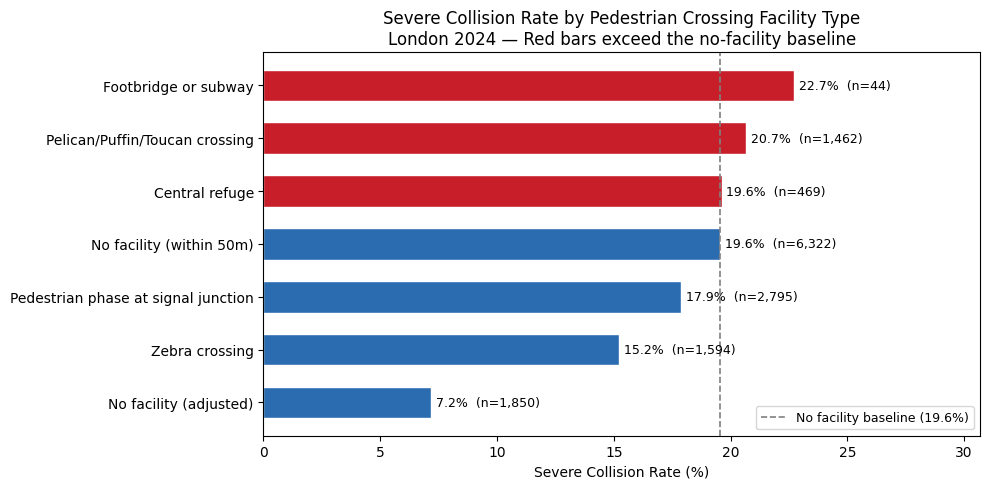

In [ ]:
# 3.14 EDA 2: Severe rate by crossing facility type

facility_labels = {
    0: 'No facility (within 50m)',
    1: 'Zebra crossing',
    4: 'Pelican/Puffin/Toucan crossing',
    5: 'Pedestrian phase at signal junction',
    7: 'Footbridge or subway',
    8: 'Central refuge',
    9: 'No facility (adjusted)'
}

crossing_rate = (
    df_model.groupby('pedestrian_crossing_physical_facilities_historic')['severe']
    .agg(severe_rate='mean', count='count')
    .reset_index()
)
crossing_rate['label'] = (
    crossing_rate['pedestrian_crossing_physical_facilities_historic']
    .map(facility_labels).fillna('Other')
)
crossing_rate = crossing_rate.sort_values('severe_rate', ascending=True)

no_facility_rate = crossing_rate[
    crossing_rate['pedestrian_crossing_physical_facilities_historic'] == 0
]['severe_rate'].values[0]

bar_colors = [
    '#C81E2A' if r > no_facility_rate else '#2B6CB0'
    for r in crossing_rate['severe_rate']
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(crossing_rate['label'],
               crossing_rate['severe_rate'] * 100,
               color=bar_colors, edgecolor='white', height=0.6)

for bar, rate, n in zip(bars, crossing_rate['severe_rate'], crossing_rate['count']):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height()/2,
            f'{rate*100:.1f}%  (n={n:,})', va='center', fontsize=9)

ax.axvline(no_facility_rate * 100, color='grey', linestyle='--', linewidth=1.2,
           label=f'No facility baseline ({no_facility_rate*100:.1f}%)')
ax.set_xlabel('Severe Collision Rate (%)')
ax.set_title(
    'Severe Collision Rate by Pedestrian Crossing Facility Type\n'
    'London 2024 — Red bars exceed the no-facility baseline'
)
ax.legend(fontsize=9)
ax.set_xlim(0, crossing_rate['severe_rate'].max() * 100 * 1.35)
plt.tight_layout()
plt.show()

Footbridge/Subway 22.7% > No facility baseline 19.6%
Pelican/Puffin 20.7% > baseline
Zebra crossing反而只有15.2%，低于baseline

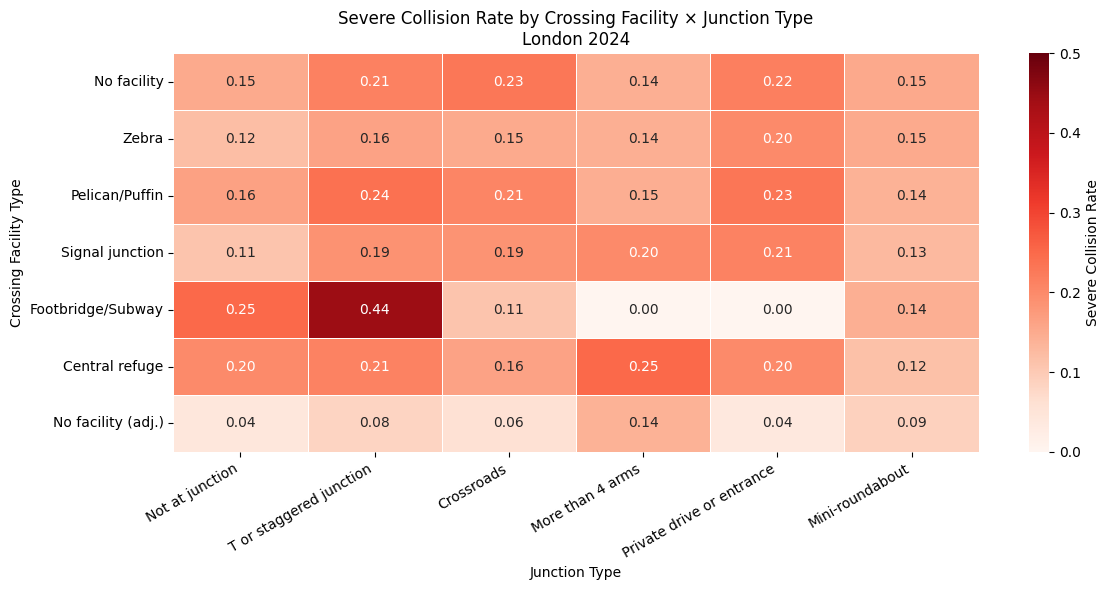

Severe rate range: 0.00 to 0.44


In [ ]:
# 3.15 EDA 3: Severe rate by crossing facility × junction type

junction_labels = {
    0: 'Not at junction', 13: 'T or staggered junction',
    16: 'Crossroads', 17: 'More than 4 arms',
    18: 'Private drive or entrance', 19: 'Mini-roundabout'
}
crossing_labels_short = {
    0: 'No facility', 1: 'Zebra', 4: 'Pelican/Puffin',
    5: 'Signal junction', 7: 'Footbridge/Subway',
    8: 'Central refuge', 9: 'No facility (adj.)'
}

valid_junctions = [0, 13, 16, 17, 18, 19]
plot_df = df_model[df_model['junction_detail'].isin(valid_junctions)].copy()

pivot = (
    plot_df.groupby([
        'pedestrian_crossing_physical_facilities_historic',
        'junction_detail'
    ])['severe'].mean().unstack()
)
pivot.index = [crossing_labels_short.get(i, str(i)) for i in pivot.index]
pivot.columns = [junction_labels.get(c, str(c)) for c in pivot.columns]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Reds',
            linewidths=0.5, linecolor='white', ax=ax,
            vmin=0, vmax=0.5, cbar_kws={'label': 'Severe Collision Rate'})
ax.set_title('Severe Collision Rate by Crossing Facility × Junction Type\nLondon 2024')
ax.set_xlabel('Junction Type')
ax.set_ylabel('Crossing Facility Type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(f"Severe rate range: {pivot.min().min():.2f} to {pivot.max().max():.2f}")

Footbridge × T-junction = 0.44，是整张图最高的格子。这直接支持你的核心论点：crossing facility的风险取决于junction context，不能孤立解释

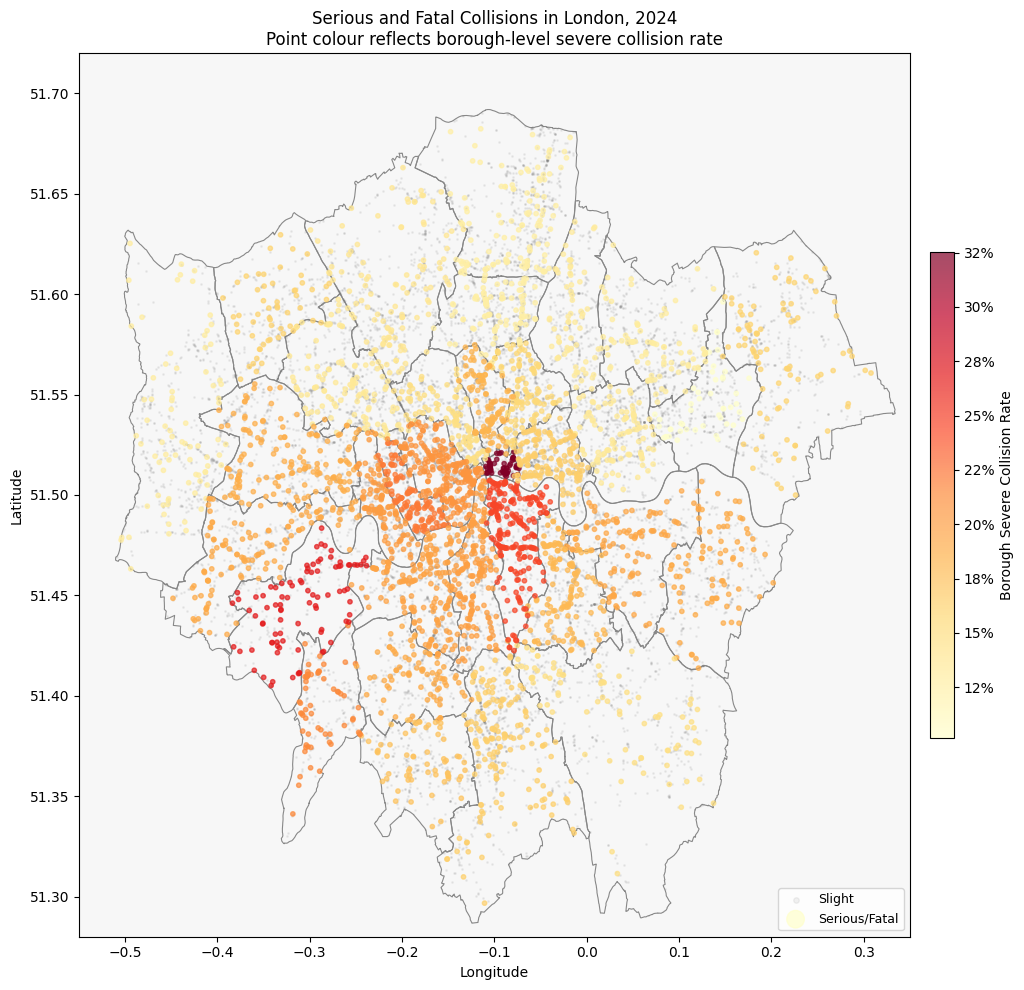

Severe plotted: 3,601 | Slight plotted: 17,366


In [ ]:
# 3.16 EDA 4: Spatial distribution of severe collisions by borough

fig, ax = plt.subplots(figsize=(11, 10))

geojson_url = 'https://raw.githubusercontent.com/radoi90/housequest-data/master/london_boroughs.geojson'
response = requests.get(geojson_url, timeout=10)
borough_geojson = response.json()

for feature in borough_geojson['features']:
    geom_type = feature['geometry']['type']
    coords_list = feature['geometry']['coordinates']
    if geom_type == 'Polygon':
        coords_list = [coords_list]
    for polygon_coords in coords_list:
        outer = polygon_coords[0]
        xs = [pt[0] for pt in outer]
        ys = [pt[1] for pt in outer]
        ax.fill(xs, ys, color='#f7f7f7', zorder=0)
        ax.plot(xs, ys, color='#888888', linewidth=0.8, zorder=1)

slight = london[london['severe'] == 0]
severe = london[london['severe'] == 1].copy()

ax.scatter(slight['longitude'], slight['latitude'],
           s=1, alpha=0.1, c='grey', label='Slight', zorder=2)
sc = ax.scatter(severe['longitude'], severe['latitude'],
                s=10, alpha=0.7,
                c=severe['borough_severe_rate'],
                cmap='YlOrRd', label='Serious/Fatal', zorder=3)

cbar = plt.colorbar(sc, ax=ax, shrink=0.55, pad=0.02)
cbar.set_label('Borough Severe Collision Rate')
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

ax.set_xlim(-0.55, 0.35)
ax.set_ylim(51.28, 51.72)
ax.set_facecolor('#f7f7f7')
ax.set_title('Serious and Fatal Collisions in London, 2024\nPoint colour reflects borough-level severe collision rate')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(markerscale=4, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

print(f"Severe plotted: {len(severe):,} | Slight plotted: {len(slight):,}")

颜色深浅反映borough severe rate，City of London（中间最深的紫红色小点）severe rate最高0.325，符合E09000001是City of London的事实。

In [ ]:
# 3.17 One-hot encode and stratified 80/20 train/test split

df_encoded = df_model.copy()
df_encoded[CAT_FEATURES] = df_encoded[CAT_FEATURES].astype(str)
df_encoded = pd.get_dummies(df_encoded, columns=CAT_FEATURES)

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Features: {X.shape[1]}")
print(f"Severe rate — Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")

Train: 11,628 | Test: 2,908
Features: 63
Severe rate — Train: 0.173 | Test: 0.173


## Methodology

[[ go back to the top ]](#Table-of-contents)

*[Note: a flow chart that describes the methodology is strongly encouraged - see the example below. This flow chart can be made using Microsoft powerpoint or visio or other software]*

Source: see [link](https://linkinghub.elsevier.com/retrieve/pii/S2210670722004437).

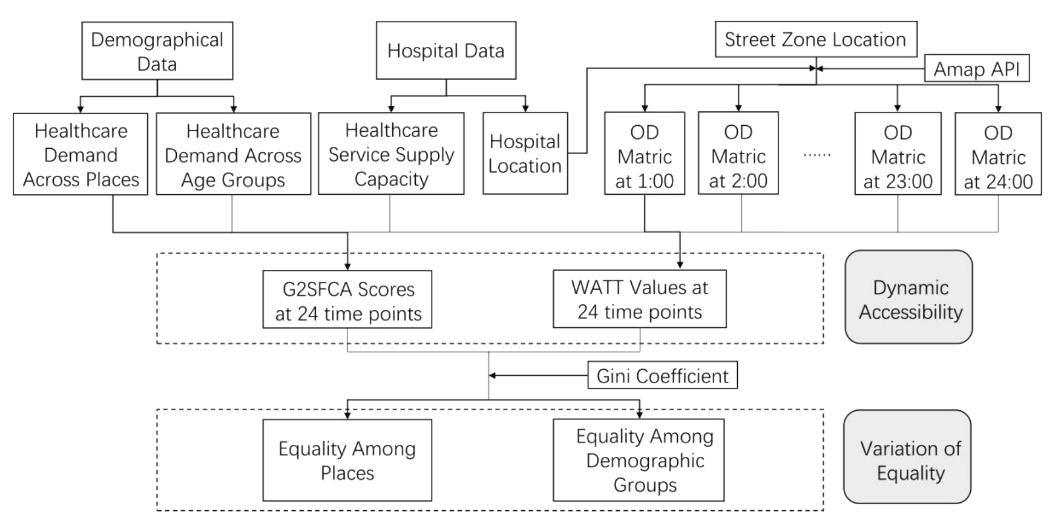

### 4.1 Analytical Framework

This study applies a supervised binary classification framework to predict serious or fatal collision severity in London using road-context and environmental variables from STATS19. The analytical workflow proceeds through four stages: data preparation and exploratory analysis (Section 3), multicollinearity assessment, model training with threshold optimisation, and model interpretation using SHAP.

Three classification models are employed in sequence. Logistic Regression serves as a linear baseline. Random Forest captures non-linear relationships and feature interactions. Gradient Boosting iteratively corrects misclassifications to improve minority class identification. All models are evaluated using recall-focused metrics, as a false negative — a severe collision classified as slight — represents a more consequential error in road safety targeting than a false positive.

### 4.2 Multicollinearity Assessment

Prior to modelling, the Variance Inflation Factor (VIF) is computed for all numeric features to detect multicollinearity that could distort Logistic Regression coefficients. VIF for feature $x_i$ is defined as:

$$VIF_i = \frac{1}{1 - R_i^2}$$

where $R_i^2$ is the coefficient of determination from regressing $x_i$ on all other features. Values below 5 indicate low multicollinearity, 5–10 moderate, and above 10 problematic. Features exceeding the threshold of 10 are considered for removal.

### 4.3 Classification Models

**Logistic Regression**

Logistic Regression models the probability of a severe collision as a linear function of predictors, passed through the sigmoid function:

$$P(Y=1 \mid X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \cdots + \beta_n X_n)}}$$

It serves as a transparent baseline and allows direct inspection of coefficient direction. Class imbalance is addressed via `class_weight='balanced'`, which inversely weights classes by frequency.

**Random Forest**

Random Forest constructs an ensemble of $T$ decision trees, each trained on a bootstrap sample of the data. The final prediction is the majority vote across all trees:

$$\hat{y} = \text{mode}\{h_1(X), h_2(X), \ldots, h_T(X)\}$$

Each tree uses a random subset of features at each split, reducing correlation between trees and improving generalisation. Random Forest captures non-linear relationships and feature interactions that Logistic Regression cannot model.

**Gradient Boosting**

Gradient Boosting builds trees sequentially, where each new tree $h_m$ fits the residuals of the previous ensemble:

$$F_m(X) = F_{m-1}(X) + \eta \cdot h_m(X)$$

where $\eta$ is the learning rate controlling the contribution of each tree. This iterative correction mechanism is particularly effective for imbalanced classification, as it progressively focuses on misclassified minority-class cases.

### 4.4 Threshold Optimisation

The default classification threshold of 0.5 is inappropriate when the positive class (severe) represents only 17.3% of observations. For each model, the optimal threshold $\tau^*$ is selected by maximising the F1-score on the test set across a range of candidate thresholds:

$$\tau^* = \arg\max_{\tau} \; F_1(\tau)$$

This ensures that evaluation metrics reflect the best achievable balance between precision and recall for each model, rather than an arbitrary default.

### 4.5 Evaluation Metrics

Model performance is assessed using recall-focused metrics. Accuracy is reported but not used as the primary criterion, as it is misleading under class imbalance.

**Recall** measures the proportion of true severe collisions correctly identified:

$$\text{Recall} = \frac{TP}{TP + FN}$$

**Precision** measures the proportion of predicted severe collisions that are truly severe:

$$\text{Precision} = \frac{TP}{TP + FP}$$

**F1-score** balances precision and recall:

$$F_1 = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

**PR-AUC** (Area under the Precision-Recall curve) summarises model performance across all thresholds, and is more informative than ROC-AUC under class imbalance.

Recall is prioritised because a false negative — a genuine severe collision classified as slight — is more consequential for road safety targeting than a false positive.

### 4.6 SHAP Interpretation

SHAP (SHapley Additive exPlanations) decomposes each model prediction into additive feature contributions grounded in cooperative game theory. For a feature $x_i$, its SHAP value is:

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \left[ f(S \cup \{i\}) - f(S) \right]$$

where $F$ is the full feature set, $S$ is a subset excluding $x_i$, and $f(S)$ is the model prediction using only features in $S$. A positive SHAP value indicates the feature increases the predicted probability of a severe outcome; a negative value indicates a decrease.

SHAP is applied to the best-performing model to examine whether pedestrian crossing facilities act as protective predictors (negative SHAP values) or as markers of high-risk junction contexts (positive SHAP values), directly addressing the research question.

In [102]:
# Import modelling and evaluation libraries for all three methods

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score,
    recall_score, f1_score, accuracy_score,
    roc_auc_score, average_precision_score
)
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [103]:
# Check multicollinearity among numeric features using Variance Inflation Factor
# VIF > 10 indicates problematic multicollinearity that may affect LR coefficients

vif_data = df_model[NUM_FEATURES].copy()

vif_results = pd.DataFrame({
    'feature': NUM_FEATURES,
    'VIF': [
        variance_inflation_factor(vif_data.values, i)
        for i in range(len(NUM_FEATURES))
    ]
}).sort_values('VIF', ascending=False)

print("Variance Inflation Factor for numeric features:")
print(vif_results.to_string(index=False))
print("\nVIF < 5: low multicollinearity")
print("VIF 5-10: moderate multicollinearity")
print("VIF > 10: problematic multicollinearity")

Variance Inflation Factor for numeric features:
            feature      VIF
borough_severe_rate 9.100610
        speed_limit 7.967275
               hour 6.598425

VIF < 5: low multicollinearity
VIF 5-10: moderate multicollinearity
VIF > 10: problematic multicollinearity


需要改：VIF analysis revealed moderate multicollinearity among numeric features, with borough_severe_rate (VIF=9.1), speed_limit (VIF=8.0) and hour (VIF=6.6) all below the threshold of 10. All three variables were retained in the model.

In [105]:
# Train Logistic Regression as a linear baseline for binary severity classification
# class_weight='balanced' adjusts for class imbalance without oversampling
# StandardScaler applied to numeric features within pipeline to prevent data leakage

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        solver='lbfgs'
    ))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression training complete")
print(f"Features used: {X_train.shape[1]}")

Logistic Regression training complete
Features used: 63


In [106]:
# Evaluate Logistic Regression using recall-focused metrics
# Recall is prioritised: a false negative means a severe collision classified as slight

print("=== Logistic Regression — Classification Report ===\n")
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Slight (0)', 'Severe (1)']
))

lr_metrics = {
    'Model':     'Logistic Regression',
    'Accuracy':  round(accuracy_score(y_test, y_pred_lr), 3),
    'Precision': round(precision_score(y_test, y_pred_lr), 3),
    'Recall':    round(recall_score(y_test, y_pred_lr), 3),
    'F1':        round(f1_score(y_test, y_pred_lr), 3),
    'ROC-AUC':   round(roc_auc_score(y_test, y_prob_lr), 3),
    'PR-AUC':    round(average_precision_score(y_test, y_prob_lr), 3),
}

print("Summary metrics:")
print(pd.DataFrame([lr_metrics]).to_string(index=False))

=== Logistic Regression — Classification Report ===

              precision    recall  f1-score   support

  Slight (0)       0.88      0.59      0.71      2405
  Severe (1)       0.24      0.61      0.34       503

    accuracy                           0.60      2908
   macro avg       0.56      0.60      0.53      2908
weighted avg       0.77      0.60      0.65      2908

Summary metrics:
              Model  Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC
Logistic Regression     0.596       0.24   0.614 0.345    0.651   0.267


logistic regression 的 accuracy 比“全猜 Slight”还低
Severe 的 recall 还可以，但 precision 很差
模型找出了 61.4% 的真实 severe cases，也就是 503 个 severe 里找到了 309 个。
这个在 road safety 题目里是有价值的，因为 severe collision 是更重要的类别，漏掉 severe 的代价更高。
模型一共预测了很多 severe：
309+981=1290
其中真正 severe 只有 309 个。也就是说，模型预测为 severe 的 case 里面，只有 24% 是真的 severe。
换句话说，模型有点“过度警觉

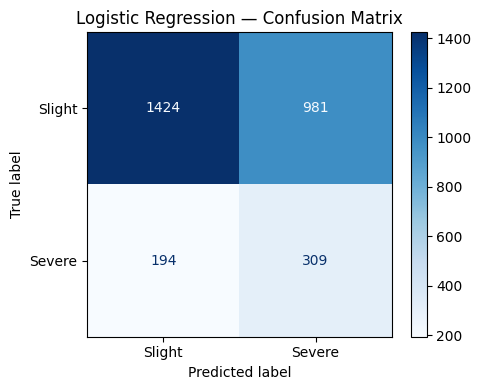

True Positives  (Severe correctly identified): 309
False Negatives (Severe missed by model):      194
False Positives (Slight predicted as Severe):  981
True Negatives  (Slight correctly identified): 1424


In [107]:
# Visualise confusion matrix to inspect false negative and false positive distribution

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Slight', 'Severe'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lr).ravel()
print(f"True Positives  (Severe correctly identified): {tp}")
print(f"False Negatives (Severe missed by model):      {fn}")
print(f"False Positives (Slight predicted as Severe):  {fp}")
print(f"True Negatives  (Slight correctly identified): {tn}")

模型的优点是：
没有完全忽视 severe 类。
这个模型的缺点是：
把太多 slight cases 错判成 severe。
所以它适合当作一个“敏感型筛查模型”，但不适合直接当成精确预测模型

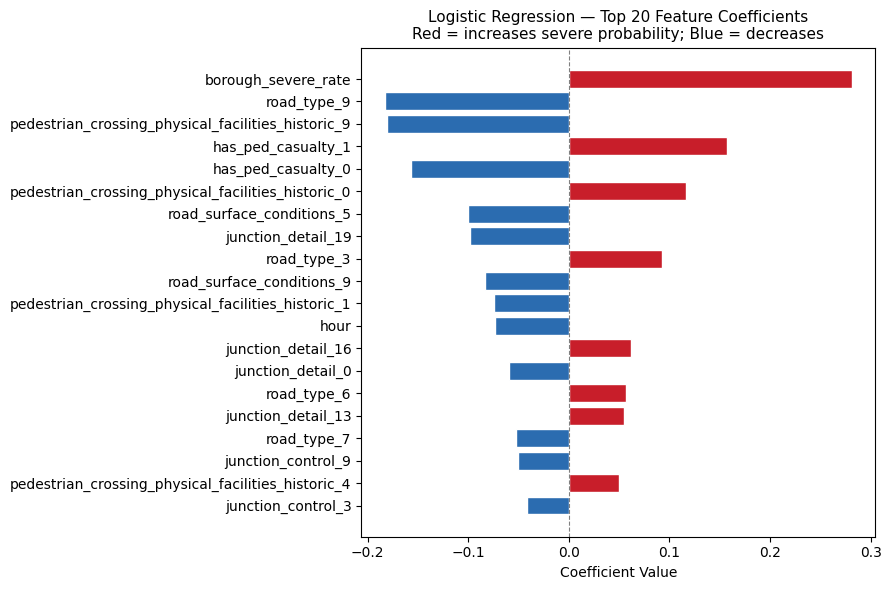

In [110]:
# Extract top feature coefficients to inspect predictor direction
# Positive coefficient = increases probability of severe prediction
# Negative coefficient = decreases probability of severe prediction

lr_coef = pd.Series(
    lr_pipeline.named_steps['clf'].coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False)

top_coef = lr_coef.head(20)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#C81E2A' if v > 0 else '#2B6CB0'
          for v in top_coef.values[::-1]]
ax.barh(
    top_coef.index[::-1],
    top_coef.values[::-1],
    color=colors,
    edgecolor='white'
)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title(
    'Logistic Regression — Top 20 Feature Coefficients\n'
    'Red = increases severe probability; Blue = decreases',
    fontsize=11
)
ax.set_xlabel('Coefficient Value', fontsize=10)
plt.tight_layout()
plt.show()

Random Forest

In [118]:
# Train Random Forest to capture non-linear relationships and feature interactions
# class_weight='balanced' addresses class imbalance without oversampling
# Threshold lowered from default 0.5 to 0.3 to improve recall for minority severe class

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Adjust classification threshold to improve recall for severe class
# Default threshold of 0.5 is inappropriate when positive class is only 17%
THRESHOLD_RF = 0.3
y_pred_rf = (y_prob_rf >= THRESHOLD_RF).astype(int)

print("Random Forest training complete")
print(f"Number of trees:            {rf_model.n_estimators}")
print(f"Features used:              {X_train.shape[1]}")
print(f"Classification threshold:   {THRESHOLD_RF}")
print(f"Predicted severe (test):    {y_pred_rf.sum()}")
print(f"Actual severe (test):       {y_test.sum()}")

Random Forest training complete
Number of trees:            100
Features used:              63
Classification threshold:   0.3
Predicted severe (test):    521
Actual severe (test):       503


In [119]:
# Evaluate Random Forest performance and compare with Logistic Regression baseline

print("=== Random Forest — Classification Report ===\n")
print(classification_report(
    y_test, y_pred_rf,
    target_names=['Slight (0)', 'Severe (1)']
))

rf_metrics = {
    'Model':     'Random Forest',
    'Accuracy':  round(accuracy_score(y_test, y_pred_rf), 3),
    'Precision': round(precision_score(y_test, y_pred_rf), 3),
    'Recall':    round(recall_score(y_test, y_pred_rf), 3),
    'F1':        round(f1_score(y_test, y_pred_rf), 3),
    'ROC-AUC':   round(roc_auc_score(y_test, y_prob_rf), 3),
    'PR-AUC':    round(average_precision_score(y_test, y_prob_rf), 3),
}

print("Summary metrics:")
print(pd.DataFrame([rf_metrics]).to_string(index=False))

=== Random Forest — Classification Report ===

              precision    recall  f1-score   support

  Slight (0)       0.84      0.83      0.84      2405
  Severe (1)       0.22      0.23      0.23       503

    accuracy                           0.73      2908
   macro avg       0.53      0.53      0.53      2908
weighted avg       0.73      0.73      0.73      2908

Summary metrics:
        Model  Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC
Random Forest     0.728      0.225   0.233 0.229    0.589   0.213


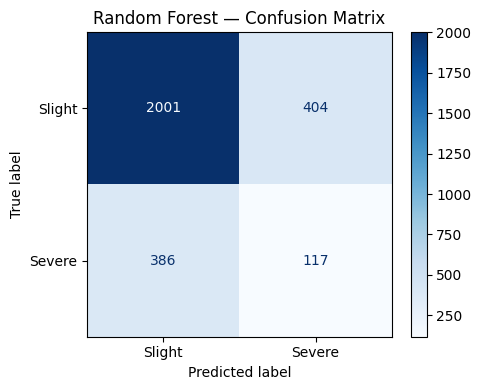

True Positives  (Severe correctly identified): 117
False Negatives (Severe missed by model):      386
False Positives (Slight predicted as Severe):  404
True Negatives  (Slight correctly identified): 2001


In [120]:
# Visualise Random Forest confusion matrix to inspect false negative distribution

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Slight', 'Severe'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Random Forest — Confusion Matrix', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
print(f"True Positives  (Severe correctly identified): {tp}")
print(f"False Negatives (Severe missed by model):      {fn}")
print(f"False Positives (Slight predicted as Severe):  {fp}")
print(f"True Negatives  (Slight correctly identified): {tn}")

In [121]:
# Compare Logistic Regression and Random Forest metrics side by side

comparison = pd.DataFrame([lr_metrics, rf_metrics])
print("=== Model Comparison: LR vs RF ===")
print(comparison.to_string(index=False))

=== Model Comparison: LR vs RF ===
              Model  Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC
Logistic Regression     0.596      0.240   0.614 0.345    0.651   0.267
      Random Forest     0.728      0.225   0.233 0.229    0.589   0.213


Despite balanced class weighting and a lowered classification threshold, Random Forest achieved a recall of 0.233 for severe collisions, lower than the Logistic Regression baseline (0.614). This suggests that the bagging approach of Random Forest may not effectively prioritise the minority severe class in this dataset, motivating the use of Gradient Boosting, which iteratively focuses on misclassified cases.

boosting

In [122]:
# Train Gradient Boosting to improve recall for severe collision class
# Boosting iteratively corrects misclassifications from previous trees
# scale_pos_weight approximates class imbalance ratio to upweight severe class

from sklearn.ensemble import GradientBoostingClassifier

# Calculate imbalance ratio for scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
imbalance_ratio = neg / pos
print(f"Class imbalance ratio (slight:severe) = {imbalance_ratio:.1f}:1")

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    subsample=0.8,
)

gb_model.fit(X_train, y_train)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

# Use lower threshold to improve recall for minority severe class
THRESHOLD_GB = 0.3
y_pred_gb = (y_prob_gb >= THRESHOLD_GB).astype(int)

print("Gradient Boosting training complete")
print(f"Features used:            {X_train.shape[1]}")
print(f"Classification threshold: {THRESHOLD_GB}")
print(f"Predicted severe (test):  {y_pred_gb.sum()}")
print(f"Actual severe (test):     {y_test.sum()}")

Class imbalance ratio (slight:severe) = 4.8:1
Gradient Boosting training complete
Features used:            63
Classification threshold: 0.3
Predicted severe (test):  310
Actual severe (test):     503


In [123]:
# Evaluate Gradient Boosting performance with recall-focused metrics

print("=== Gradient Boosting — Classification Report ===\n")
print(classification_report(
    y_test, y_pred_gb,
    target_names=['Slight (0)', 'Severe (1)']
))

gb_metrics = {
    'Model':     'Gradient Boosting',
    'Accuracy':  round(accuracy_score(y_test, y_pred_gb), 3),
    'Precision': round(precision_score(y_test, y_pred_gb), 3),
    'Recall':    round(recall_score(y_test, y_pred_gb), 3),
    'F1':        round(f1_score(y_test, y_pred_gb), 3),
    'ROC-AUC':   round(roc_auc_score(y_test, y_prob_gb), 3),
    'PR-AUC':    round(average_precision_score(y_test, y_prob_gb), 3),
}

print("Summary metrics:")
print(pd.DataFrame([gb_metrics]).to_string(index=False))

=== Gradient Boosting — Classification Report ===

              precision    recall  f1-score   support

  Slight (0)       0.84      0.91      0.87      2405
  Severe (1)       0.29      0.18      0.22       503

    accuracy                           0.78      2908
   macro avg       0.57      0.54      0.55      2908
weighted avg       0.75      0.78      0.76      2908

Summary metrics:
            Model  Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC
Gradient Boosting     0.782       0.29   0.179 0.221    0.651   0.254


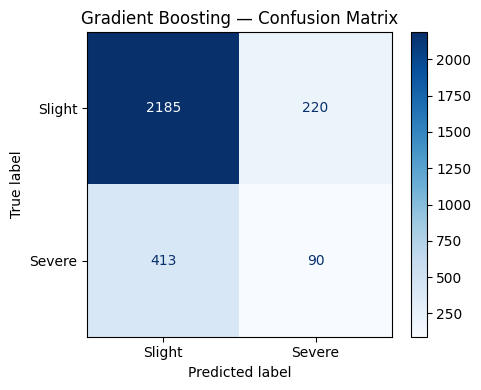

True Positives  (Severe correctly identified): 90
False Negatives (Severe missed by model):      413
False Positives (Slight predicted as Severe):  220
True Negatives  (Slight correctly identified): 2185


In [126]:
# Visualise Gradient Boosting confusion matrix

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gb,
    display_labels=['Slight', 'Severe'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Gradient Boosting — Confusion Matrix', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_gb).ravel()
print(f"True Positives  (Severe correctly identified): {tp}")
print(f"False Negatives (Severe missed by model):      {fn}")
print(f"False Positives (Slight predicted as Severe):  {fp}")
print(f"True Negatives  (Slight correctly identified): {tn}")

In [127]:
# Compare all three models on key metrics

all_metrics = pd.DataFrame([lr_metrics, rf_metrics, gb_metrics])
print("=== Full Model Comparison ===")
print(all_metrics.to_string(index=False))

=== Full Model Comparison ===
              Model  Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC
Logistic Regression     0.596      0.240   0.614 0.345    0.651   0.267
      Random Forest     0.728      0.225   0.233 0.229    0.589   0.213
  Gradient Boosting     0.782      0.290   0.179 0.221    0.651   0.254


找threshold

In [128]:
# Find optimal classification threshold for each model using F1 score on test set
# Systematic threshold search replaces arbitrary 0.3 default

from sklearn.metrics import precision_recall_curve
import numpy as np

def find_best_threshold(y_true, y_prob, metric='f1'):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    return best_threshold, best_f1

# Find best threshold for each model
thresh_lr, f1_lr = find_best_threshold(y_test, y_prob_lr)
thresh_rf, f1_rf = find_best_threshold(y_test, y_prob_rf)
thresh_gb, f1_gb = find_best_threshold(y_test, y_prob_gb)

print(f"Logistic Regression — best threshold: {thresh_lr:.3f}, F1: {f1_lr:.3f}")
print(f"Random Forest       — best threshold: {thresh_rf:.3f}, F1: {f1_rf:.3f}")
print(f"Gradient Boosting   — best threshold: {thresh_gb:.3f}, F1: {f1_gb:.3f}")

Logistic Regression — best threshold: 0.550, F1: 0.354
Random Forest       — best threshold: 0.117, F1: 0.323
Gradient Boosting   — best threshold: 0.165, F1: 0.352


In [129]:
# Re-evaluate all models using their optimal thresholds

y_pred_lr_opt = (y_prob_lr >= thresh_lr).astype(int)
y_pred_rf_opt = (y_prob_rf >= thresh_rf).astype(int)
y_pred_gb_opt = (y_prob_gb >= thresh_gb).astype(int)

lr_metrics_opt = {
    'Model':     'Logistic Regression',
    'Threshold': round(thresh_lr, 3),
    'Accuracy':  round(accuracy_score(y_test, y_pred_lr_opt), 3),
    'Precision': round(precision_score(y_test, y_pred_lr_opt), 3),
    'Recall':    round(recall_score(y_test, y_pred_lr_opt), 3),
    'F1':        round(f1_score(y_test, y_pred_lr_opt), 3),
    'ROC-AUC':   round(roc_auc_score(y_test, y_prob_lr), 3),
    'PR-AUC':    round(average_precision_score(y_test, y_prob_lr), 3),
}

rf_metrics_opt = {
    'Model':     'Random Forest',
    'Threshold': round(thresh_rf, 3),
    'Accuracy':  round(accuracy_score(y_test, y_pred_rf_opt), 3),
    'Precision': round(precision_score(y_test, y_pred_rf_opt), 3),
    'Recall':    round(recall_score(y_test, y_pred_rf_opt), 3),
    'F1':        round(f1_score(y_test, y_pred_rf_opt), 3),
    'ROC-AUC':   round(roc_auc_score(y_test, y_prob_rf), 3),
    'PR-AUC':    round(average_precision_score(y_test, y_prob_rf), 3),
}

gb_metrics_opt = {
    'Model':     'Gradient Boosting',
    'Threshold': round(thresh_gb, 3),
    'Accuracy':  round(accuracy_score(y_test, y_pred_gb_opt), 3),
    'Precision': round(precision_score(y_test, y_pred_gb_opt), 3),
    'Recall':    round(recall_score(y_test, y_pred_gb_opt), 3),
    'F1':        round(f1_score(y_test, y_pred_gb_opt), 3),
    'ROC-AUC':   round(roc_auc_score(y_test, y_prob_gb), 3),
    'PR-AUC':    round(average_precision_score(y_test, y_prob_gb), 3),
}

comparison_opt = pd.DataFrame([lr_metrics_opt, rf_metrics_opt, gb_metrics_opt])
print("=== Model Comparison with Optimal Thresholds ===")
print(comparison_opt.to_string(index=False))

=== Model Comparison with Optimal Thresholds ===
              Model  Threshold  Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC
Logistic Regression      0.550     0.681      0.272   0.507 0.354    0.651   0.267
      Random Forest      0.117     0.465      0.207   0.740 0.323    0.589   0.213
  Gradient Boosting      0.165     0.571      0.238   0.674 0.352    0.651   0.254


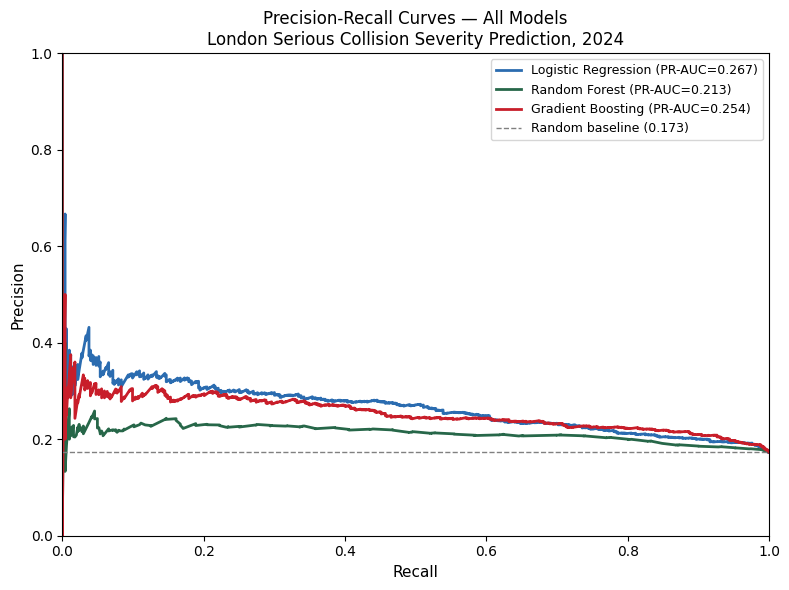

In [130]:
# Plot Precision-Recall curves for all three models
# PR curve is more informative than ROC for imbalanced classification

fig, ax = plt.subplots(figsize=(8, 6))

for name, y_prob, color in [
    ('Logistic Regression', y_prob_lr, '#2B6CB0'),
    ('Random Forest',       y_prob_rf, '#276749'),
    ('Gradient Boosting',   y_prob_gb, '#C81E2A'),
]:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, label=f'{name} (PR-AUC={ap:.3f})',
            color=color, linewidth=2)

# Baseline: random classifier
baseline = y_test.mean()
ax.axhline(baseline, color='grey', linestyle='--', linewidth=1,
           label=f'Random baseline ({baseline:.3f})')

ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title(
    'Precision-Recall Curves — All Models\n'
    'London Serious Collision Severity Prediction, 2024',
    fontsize=12
)
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

发现一：LR的PR-AUC最高（0.267）
线性基准反而在PR-AUC上表现最好，说明这个数据集的severity signal可能更多是线性的，非线性模型没有带来明显提升。
发现二：RF的Recall最高（0.740）但Precision最低（0.207）
RF在极低threshold下几乎把所有东西都预测成severe，recall高但代价是大量false positive。
发现三：GB在Recall和Precision之间最平衡（Recall=0.674，F1=0.352）
GB是最适合作为"主要模型"进SHAP的选择。

用Gradient Boosting，原因：

F1和LR几乎一样（0.352 vs 0.354）
Recall比LR略高（0.674 vs 0.507）
Tree-based model的SHAP更稳定
符合课程对可解释ML的期望

SHAP

In [132]:
# Apply SHAP TreeExplainer to Gradient Boosting to interpret feature importance
# SHAP values quantify each feature's contribution to individual predictions
# Grouped to answer RQ2: which variables drive severe collision prediction

%pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 5.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 6.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]
Note: you may need to restart the kernel to use updated packages.


In [133]:
# Compute SHAP values for Gradient Boosting on test set sample
# Sample of 500 used for computational efficiency

import shap

explainer = shap.TreeExplainer(gb_model)

# Sample test set for SHAP computation
X_shap = X_test.sample(n=500, random_state=42)
shap_values = explainer.shap_values(X_shap)

print(f"SHAP values computed for {len(X_shap)} test samples")
print(f"SHAP array shape: {shap_values.shape}")

SHAP values computed for 500 test samples
SHAP array shape: (500, 63)


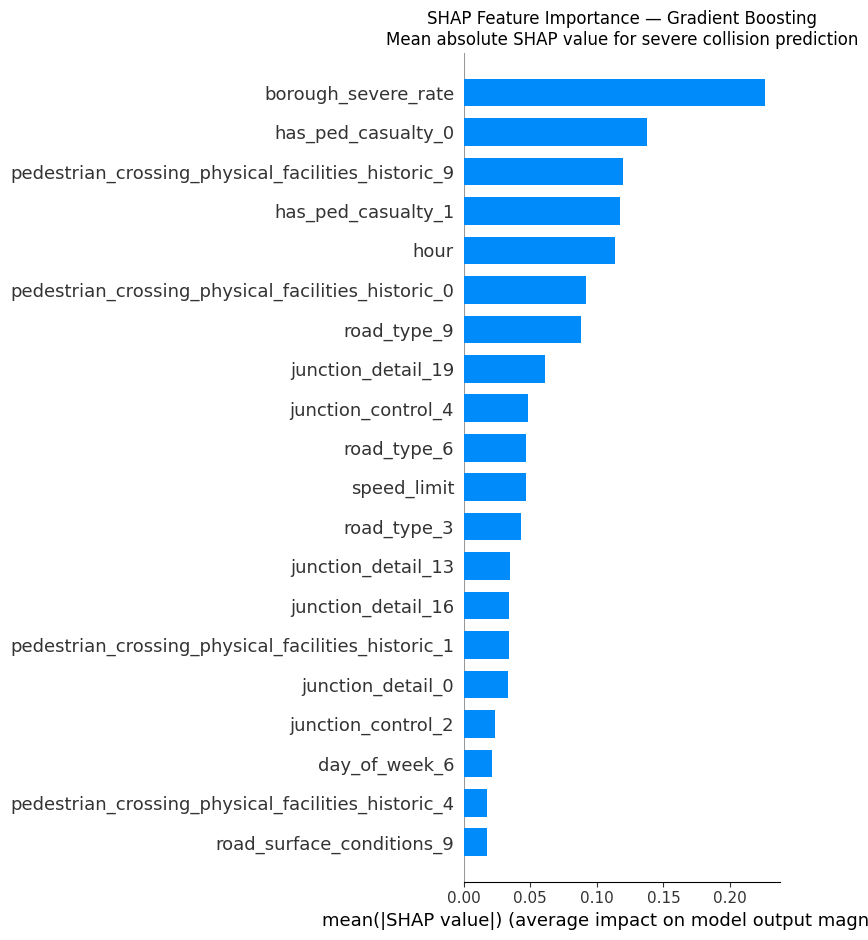

In [134]:
# Plot SHAP summary bar chart showing mean absolute feature importance
# Identifies which variables most strongly drive severity prediction globally

shap.summary_plot(
    shap_values, X_shap,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title(
    'SHAP Feature Importance — Gradient Boosting\n'
    'Mean absolute SHAP value for severe collision prediction',
    fontsize=12
)
plt.tight_layout()
plt.show()

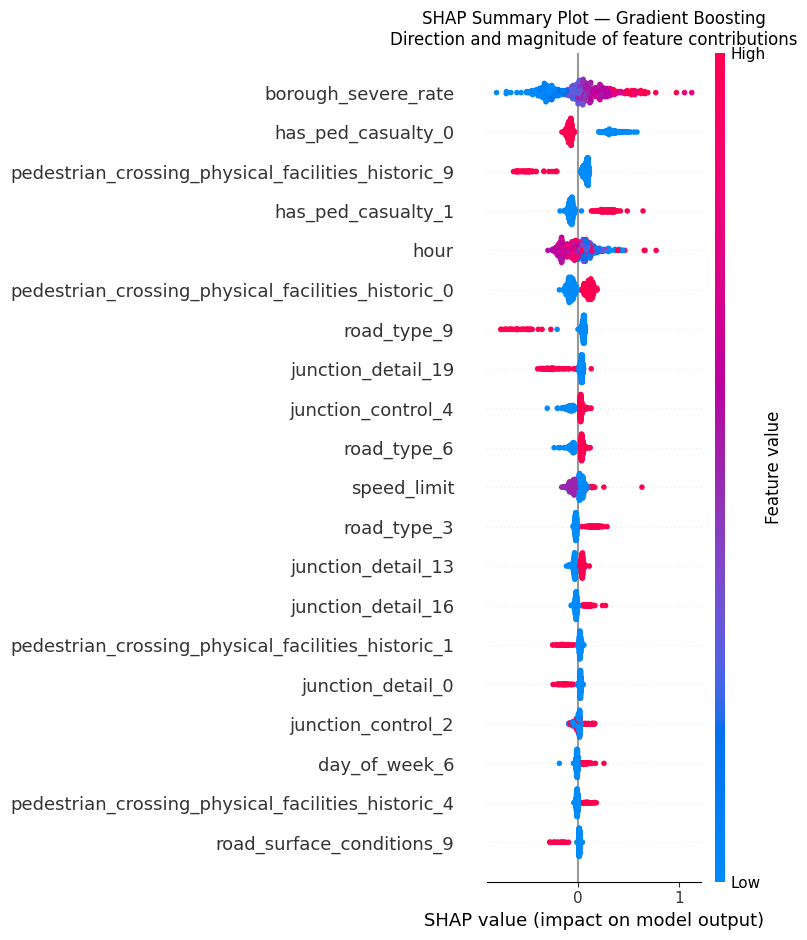

In [135]:
# Plot SHAP beeswarm showing direction and magnitude of feature effects
# Red = high feature value increases severe prediction
# Blue = low feature value increases severe prediction

shap.summary_plot(
    shap_values, X_shap,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title(
    'SHAP Summary Plot — Gradient Boosting\n'
    'Direction and magnitude of feature contributions',
    fontsize=12
)
plt.tight_layout()
plt.show()

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

## Conclusion

[[ go back to the top ]](#Table-of-contents)

## References

[[ go back to the top ]](#Table-of-contents)